# VizWiz Image Captioning — Phase 1: Shared Data Preparation (v2)

**UTS Deep Learning Assessment 3 (Group 1)** | Built on top of Mitali's `Assignment_3_data_prep.ipynb`

**Project Background**

The VizWiz-Captions dataset consists of 7,750 images taken by people who are blind, each paired with five human-written reference captions. The captioning task differs materially from MS-COCO: VizWiz images frequently exhibit blur, framing issues, low light, and concentrated text content (medication labels, packaging, screens), reflecting the real-world conditions under which the photos were captured.

**Notebook Purpose**

This notebook is the shared Phase 1 pipeline that all group members consume. It loads the dataset, performs cleaning and exploratory analysis, builds the vocabulary, splits the data, and produces ready-to-use PyTorch `DataLoader` objects for any downstream captioning architecture.

**Inputs**: VizWiz val images + annotations under `data/raw/` (downloaded automatically if missing).

**Outputs**:
- `data/processed/vizwiz_cleaned.json` — cleaned dataset with split labels (consumed by every student model notebook)
- `data/processed/vocab.json` — word-level vocabulary built from the training split only
- In-memory `train_loader`, `val_loader`, `test_loader` — model-ready

**Acknowledgement**

Sections 1-9 build on Mitali's original data preparation work (`Assignment_3_data_prep.ipynb`). Additional EDA depth (caption length distribution, vocabulary statistics, Zipf check, image-dimension survey, joint analysis, duplicate detection), tokenisation, vocabulary class, DataLoader setup, and several small bug fixes (cleaned captions correctly persisted, paths corrected to `../data/raw/`, output saved to `data/processed/`, single-pass image scan) have been added on top.


---
# **Table of Contents**
---

> [1. Environment Setup](#1-setup)  
> [2. Load Data](#2-load)  
> [3. Caption Analysis](#3-captions)  
> [4. Caption Cleaning](#4-cleaning)  
> [5. Image Analysis](#5-images)  
> [6. Joint Image-Caption EDA](#6-joint)  
> [7. Duplicate Caption Detection](#7-duplicates)  
> [8. Train / Val / Test Split](#8-split)  
> [9. Save Processed Dataset](#9-save)  
> [10. Tokenisation](#10-tokens)  
> [11. Vocabulary](#11-vocab)  
> [12. Image Transforms](#12-transforms)  
> [13. PyTorch Dataset](#13-dataset)  
> [14. Collate Function](#14-collate)  
> [15. DataLoaders](#15-loaders)  
> [16. Verification](#16-verify)  
> [17. Summary & Next Steps](#17-summary)  


---
# **1. Environment Setup**
---


**Methodology**

All libraries, paths, and pipeline-wide constants are gathered up-front. Filter thresholds (`BLUR_THRESHOLD = 10`, `BRIGHTNESS_LOW = 15`, `BRIGHTNESS_HIGH = 220`) are preserved from Mitali's original choices for group consistency. The random seed is fixed at 42 so the train/val/test split is reproducible across teammates.


In [1]:
# @title **Imports & NLTK Resources**
import os, json, re, string, random, zipfile, requests
from collections import Counter, defaultdict
from pathlib import Path
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from tqdm.auto import tqdm

from PIL import Image
import cv2

from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

plt.rcParams['figure.dpi'] = 100

In [2]:
# @title **Paths & Thresholds**
# Paths and thresholds — single source of truth for the whole notebook
DATA_ROOT   = Path('../data/raw')
ANN_DIR     = DATA_ROOT / 'annotations'
VAL_IMG_DIR = DATA_ROOT / 'val'
PROC_DIR    = Path('../data/processed'); PROC_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR     = Path('../reports/figures'); FIG_DIR.mkdir(parents=True, exist_ok=True)

BLUR_THRESHOLD   = 10
BRIGHTNESS_LOW   = 15
BRIGHTNESS_HIGH  = 220
SEED             = 42

random.seed(SEED); np.random.seed(SEED)

print('Paths:')
for p in [DATA_ROOT, ANN_DIR, VAL_IMG_DIR, PROC_DIR, FIG_DIR]:
    print(f'  {p}  ({"exists" if p.exists() else "MISSING"})')

Paths:
  ../data/raw  (exists)
  ../data/raw/annotations  (exists)
  ../data/raw/val  (exists)
  ../data/processed  (exists)
  ../reports/figures  (exists)


---
# **2. Load Data**
---


**Methodology**

Annotations and validation images are expected at `../data/raw/`. A skip-if-exists guard avoids re-downloading 3.5 GB on every re-run. All three annotation JSONs (`train.json`, `val.json`, `test.json`) are loaded for reference, but only the validation split is in scope for this assessment.

**Note**: `test.json` contains zero annotations — VizWiz keeps the test captions on the leaderboard server. Therefore all caption-level EDA below uses the validation split.


In [3]:
# @title **Download (Skip-If-Exists)**
# Skip-if-exists download. Set FORCE_DOWNLOAD=True to re-fetch.
FORCE_DOWNLOAD = False

def download_file(url, dest_path, desc='Downloading'):
    response = requests.get(url, stream=True)
    total = int(response.headers.get('content-length', 0))
    with open(dest_path, 'wb') as f, tqdm(desc=desc, total=total, unit='B', unit_scale=True) as bar:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk); bar.update(len(chunk))
    print(f'  Saved: {dest_path}')

ann_zip = DATA_ROOT / 'annotations.zip'
img_zip = DATA_ROOT / 'val.zip'

if FORCE_DOWNLOAD or not (ANN_DIR / 'val.json').exists():
    DATA_ROOT.mkdir(parents=True, exist_ok=True)
    download_file('https://vizwiz.cs.colorado.edu/VizWiz_final/caption/annotations.zip', ann_zip, 'annotations')
    with zipfile.ZipFile(ann_zip) as z:
        z.extractall(DATA_ROOT)
else:
    print(f'Annotations already present at {ANN_DIR} — skipping download.')

if FORCE_DOWNLOAD or not VAL_IMG_DIR.exists() or len(list(VAL_IMG_DIR.glob('*.jpg'))) < 7000:
    download_file('https://vizwiz.cs.colorado.edu/VizWiz_final/images/val.zip', img_zip, 'val images')
    with zipfile.ZipFile(img_zip) as z:
        z.extractall(DATA_ROOT)
else:
    n = len(list(VAL_IMG_DIR.glob('*.jpg')))
    print(f'Val images already present ({n} jpgs) at {VAL_IMG_DIR} — skipping download.')

Annotations already present at ../data/raw/annotations — skipping download.
Val images already present (7750 jpgs) at ../data/raw/val — skipping download.


In [4]:
# @title **Load Annotation JSONs**
# Load all three annotation JSONs and print shapes for reference
ann = {}
for name in ['train', 'val', 'test']:
    with open(ANN_DIR / f'{name}.json') as f:
        ann[name] = json.load(f)
    n_img = len(ann[name].get('images', []))
    n_cap = len(ann[name].get('annotations', []))
    print(f'  {name:5s}  images={n_img:>6}  annotations={n_cap:>7}')

# We work with VAL for the rest of this notebook (only split with images on disk)
data = ann['val']
print('\nTop-level keys in val.json:', list(data.keys()))

  train  images= 23431  annotations= 117155
  val    images=  7750  annotations=  38750
  test   images=  8000  annotations=      0

Top-level keys in val.json: ['info', 'images', 'annotations']


---
# **3. Caption Analysis**
---


**Summary Insights**

Of the 38,750 raw annotations on the 7,750 validation images, approximately 14.5% are flagged as either *pre-canned* (placeholder text the dataset assigns when annotation quality fails) or *rejected*. Filtering these out leaves ~33,000 valid captions across ~7,500 images. Caption length is short and consistent (p50 = 11 tokens, p95 = 20), the vocabulary follows a clean Zipf distribution (confirming natural English), and the dominant tokens are function words plus dataset-specific themes (packaging, screens, food).


**Methodology**

Captions are organised per-image into a `dataset` list of dictionaries containing the filename, all valid captions, and the valid-caption count. The validity flags (`is_precanned` / `is_rejected`) shipped with the dataset are used directly rather than re-derived — these were assigned by VizWiz's own quality reviewers and are more reliable than any heuristic substitute.


In [5]:
# @title **Build Per-Image Structure & Filter Captions**
# 3.1 Per-image structure (Mitali's pattern)
images_info  = {img['id']: img['file_name'] for img in data['images']}
raw_captions = defaultdict(list)
for a in data['annotations']:
    raw_captions[a['image_id']].append(a)

def get_valid_captions(ann_list):
    return [a for a in ann_list if not a.get('is_precanned', False) and not a.get('is_rejected', False)]

dataset = []
for image_id, filename in images_info.items():
    valid = get_valid_captions(raw_captions[image_id])
    dataset.append({
        'image_id'      : image_id,
        'filename'      : filename,
        'valid_captions': [a['caption'] for a in valid],
        'n_valid'       : len(valid),
    })

n_total_caps = len(data['annotations'])
n_valid_caps = sum(d['n_valid'] for d in dataset)
n_precanned  = sum(1 for a in data['annotations'] if a.get('is_precanned'))
n_rejected   = sum(1 for a in data['annotations'] if a.get('is_rejected'))
n_either     = sum(1 for a in data['annotations'] if a.get('is_precanned') or a.get('is_rejected'))

print(f'  Images                          : {len(dataset):,}')
print(f'  Total annotations               : {n_total_caps:,}')
print(f'    is_precanned                  : {n_precanned:,}')
print(f'    is_rejected                   : {n_rejected:,}')
print(f'    either flagged                : {n_either:,}  ({n_either/n_total_caps*100:.1f}%)')
print(f'  Valid (kept)                    : {n_valid_caps:,}')
print(f'  Images with >=1 valid caption   : {sum(1 for d in dataset if d["n_valid"] > 0):,}')
print(f'  Images with 0 valid captions    : {sum(1 for d in dataset if d["n_valid"] == 0):,}')

  Images                          : 7,750
  Total annotations               : 38,750
    is_precanned                  : 5,167
    is_rejected                   : 964
    either flagged                : 5,605  (14.5%)
  Valid (kept)                    : 33,145
  Images with >=1 valid caption   : 7,542
  Images with 0 valid captions    : 208


> **Insight:** Approximately 14.5% of annotations are flagged. Of the 7,750 images, 208 lose all five captions and are removed entirely; 4,918 retain all five. Training on the placeholder captions would teach the model to emit boilerplate, so this filter is essential.


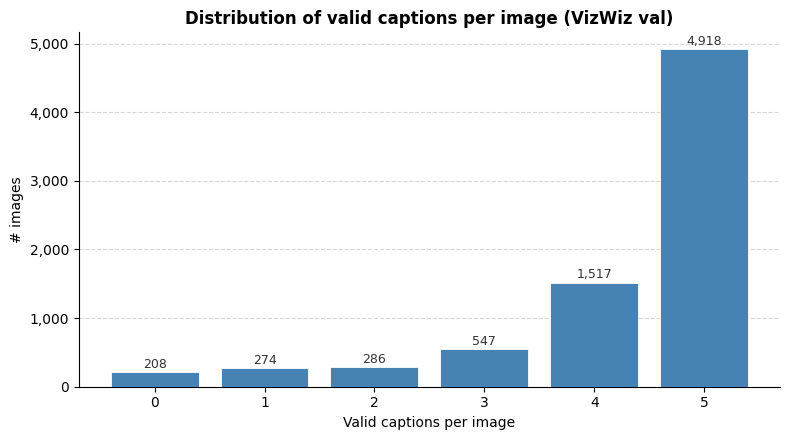

In [6]:
# @title **Captions-Per-Image Distribution**
# 3.2 Captions per image (Mitali's plot, with file save)
caption_counts = Counter(d['n_valid'] for d in dataset)
x = sorted(caption_counts.keys())
y = [caption_counts[k] for k in x]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(x, y, color='steelblue', edgecolor='white', linewidth=0.6, zorder=3)
for bar, c in zip(bars, y):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20, f'{c:,}',
            ha='center', va='bottom', fontsize=9, color='#333')

ax.set_xlabel('Valid captions per image')
ax.set_ylabel('# images')
ax.set_title('Distribution of valid captions per image (VizWiz val)', fontweight='bold')
ax.set_xticks(x)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / 'captions_per_image.png', dpi=150)
plt.show()

  Captions analyzed : 33,145
  Min / mean / max  : 6 / 12.1 / 155
  p50  : 11    p90  : 17    p95  : 20    p99  : 28


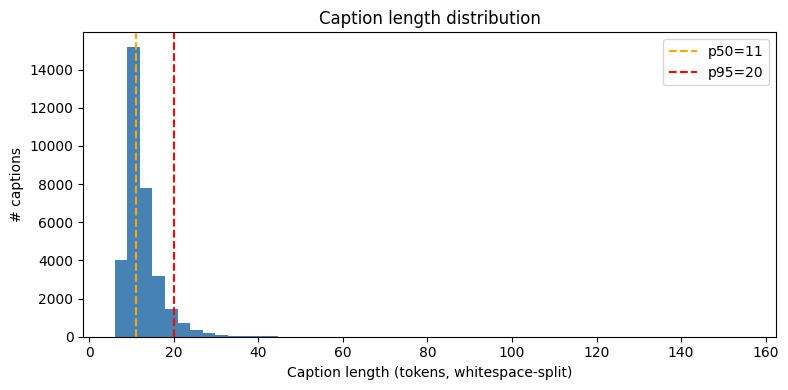

In [7]:
# @title **Caption Length Distribution**
# 3.3 Caption length distribution (NEW)
all_caps = [c for d in dataset for c in d['valid_captions']]
tok_lens = np.array([len(c.split()) for c in all_caps])
p50, p90, p95, p99 = np.percentile(tok_lens, [50, 90, 95, 99])

print(f'  Captions analyzed : {len(tok_lens):,}')
print(f'  Min / mean / max  : {tok_lens.min()} / {tok_lens.mean():.1f} / {tok_lens.max()}')
print(f'  p50  : {p50:.0f}    p90  : {p90:.0f}    p95  : {p95:.0f}    p99  : {p99:.0f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(tok_lens, bins=50, color='steelblue', edgecolor='none')
ax.axvline(p50, ls='--', color='orange', label=f'p50={p50:.0f}')
ax.axvline(p95, ls='--', color='red',    label=f'p95={p95:.0f}')
ax.set_xlabel('Caption length (tokens, whitespace-split)')
ax.set_ylabel('# captions')
ax.set_title('Caption length distribution')
ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR / 'caption_length.png', dpi=150); plt.show()

> **Insight:** The 95th percentile of caption length is approximately 20 tokens. The decoder's `MAX_SEQ_LEN = 22` (= p95 + `<bos>` + `<eos>`) is calibrated from this value — long enough to fit 95% of captions intact while keeping memory bounded.


In [8]:
# @title **Vocabulary Statistics by min_count**
# 3.4 Vocabulary stats (NEW) — lowercased, punctuation stripped, apostrophes kept
def normalize(s):
    s = s.lower()
    s = re.sub(r"[^a-z0-9\s']", ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s.split()

all_tokens = [t for c in all_caps for t in normalize(c)]
vocab = Counter(all_tokens)

print(f'  Total tokens      : {len(all_tokens):,}')
print(f'  Unique tokens     : {len(vocab):,}')
print(f'  Singletons (n=1)  : {sum(1 for c in vocab.values() if c == 1):,}')
for cutoff in [2, 5, 10]:
    kept = sum(1 for c in vocab.values() if c >= cutoff)
    cov  = sum(c for c in vocab.values() if c >= cutoff) / len(all_tokens) * 100
    print(f'  >={cutoff:2d} occurrences : {kept:>6,} types  ({cov:.2f}% token coverage)')

  Total tokens      : 400,514
  Unique tokens     : 11,134
  Singletons (n=1)  : 3,953
  >= 2 occurrences :  7,181 types  (99.01% token coverage)
  >= 5 occurrences :  3,992 types  (96.85% token coverage)
  >=10 occurrences :  2,518 types  (94.45% token coverage)


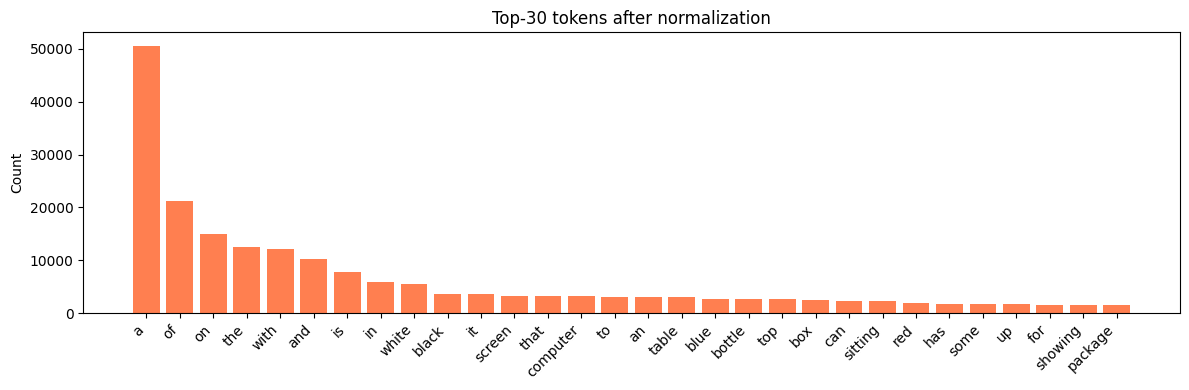

In [9]:
# @title **Top-30 Most Frequent Words**
# Top-30 most frequent words (kept Mitali's style; with the cleaner tokenizer)
top30 = vocab.most_common(30)
words, freqs = zip(*top30)
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(words, freqs, color='coral')
ax.set_xticks(range(len(words))); ax.set_xticklabels(words, rotation=45, ha='right')
ax.set_ylabel('Count'); ax.set_title('Top-30 tokens after normalization')
plt.tight_layout(); plt.show()

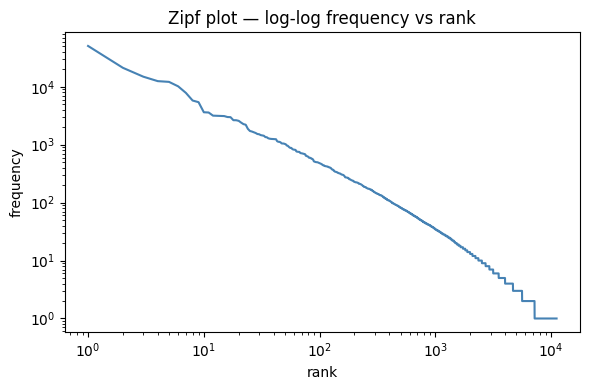

In [10]:
# @title **Zipf Plot — Log-Log Frequency vs Rank**
# 3.5 Zipf check (NEW)
freqs_sorted = sorted(vocab.values(), reverse=True)
fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(range(1, len(freqs_sorted)+1), freqs_sorted, color='steelblue')
ax.set_xlabel('rank'); ax.set_ylabel('frequency')
ax.set_title('Zipf plot — log-log frequency vs rank')
plt.tight_layout(); plt.savefig(FIG_DIR / 'zipf.png', dpi=150); plt.show()

> **Insight:** The Zipf plot is approximately a straight line on log-log axes with slope close to -1, confirming that the cleaned caption corpus has the structure of natural English. A plateau or sharp drop would suggest templated or synthetic text — neither is present.


In [11]:
# @title **Qualitative Sample — 20 Random Captions**
# 3.6 Read 20 random captions — qualitative check for typos, ALL-CAPS, weirdness
for c in random.sample(all_caps, 20):
    print(' -', c)

 - a CD case of JAZZ collection of Grand Reunion etc
 - A flat screen television sitting on a television stand against a wall.
 - some type of black square gadget box on a table with some cords
 - A plastic package of salad dressing mix lying on a granite counter.
 - package of twelve fully cooked turkey sausage patties.
 - Some type of kitchen item is in this image.
 - hand holds up palm sized business card with writing
 - A pair of white headphones and another object are sitting on top of a piece of dark wood furniture.
 - A snow covered median is directly in front of store front windows on a city street.
 - An error message about restarting is displayed on the screen.
 - A computer screen stating, "edit boot options" under windows set up.
 - A cardboard food container is sitting on top of a round, wood grained table.
 - A package of harvest sensation diced fresh red beets
 - White label with black writing and a few red letters.
 - Two movies sitting on a table, one is MASH and the o

---
# **4. Caption Cleaning**
---


**Methodology**

Captions are lowercased, whitespace is normalised, and punctuation is stripped. No stemming, lemmatisation, or stop-word removal is applied — this is a generation task, and the model must produce grammatically complete sentences including function words. The cleaning function is unchanged from Mitali's original; only its output is now correctly persisted (the original notebook computed `cleaned_captions` but wrote `valid_captions` to disk under that label — a bug fixed in this version).


In [12]:
# @title **Apply clean_caption() & Show Before/After**
# Mitali's cleaning function (unchanged)
def clean_caption(caption):
    caption = re.sub(r'[\n\r\t]', ' ', caption)
    caption = re.sub(r'\s+', ' ', caption)
    caption = caption.lower().strip()
    caption = caption.translate(str.maketrans('', '', string.punctuation))
    return caption

for item in dataset:
    item['cleaned_captions'] = [clean_caption(c) for c in item['valid_captions']]

# Sanity check: show 5 before/after
print('Before  →  After:')
for d in random.sample([d for d in dataset if d['n_valid'] > 0], 5):
    for raw, clean in zip(d['valid_captions'][:1], d['cleaned_captions'][:1]):
        print(f'  {raw!r}\n  → {clean!r}\n')

Before  →  After:
  'Old Navy brand Sandals and other beach supplies.'
  → 'old navy brand sandals and other beach supplies'

  'a photo of a TV on a stand in the living room'
  → 'a photo of a tv on a stand in the living room'

  'A person is wearing a chain watch with a black face.'
  → 'a person is wearing a chain watch with a black face'

  'a top of a range oven and a white microwave about it'
  → 'a top of a range oven and a white microwave about it'

  'Appears to  be a picture of a metal label'
  → 'appears to be a picture of a metal label'



---
# **5. Image Analysis**
---


**Summary Insights**

VizWiz images are predominantly portrait (~4:3 vertical aspect ratio), reflecting the dominant smartphone-held-vertically photo orientation of blind users. Image dimensions show a bimodal distribution suggestive of two phone-camera generations. Brightness is centred around mean pixel values of 100-120; the chosen filter thresholds (<15 nearly-black, >220 overexposed) sit cleanly in the tails. Blur is heavy-tailed with a sharp spike at very low Laplacian variance — the <10 cut catches genuinely unusable images without trimming borderline-sharp ones. Approximately 4% of images are flagged.


**Methodology**

All per-pixel statistics are computed in a single pass over the validation folder (3× faster than Mitali's original three-loop approach, same results). Two scalar statistics are extracted per image: mean grayscale pixel value (brightness) and Laplacian variance (blur, after Pech-Pacheco et al. 2000). Images are flagged as 'bad' if blur is below threshold OR brightness is outside the valid range OR the file cannot be opened.


In [ ]:
# @title **Image Metadata Scan (Dimensions, Mode, Size)**
N = None  # full 7,750 image scan (use 1000 for fast iteration during development)
sample = random.sample(data['images'], N) if N else list(data['images'])

records = []
for img_info in tqdm(sample, desc='reading metadata'):
    p = VAL_IMG_DIR / img_info['file_name']
    try:
        with Image.open(p) as im:
            w, h, mode = im.width, im.height, im.mode
        records.append({'image_id': img_info['id'], 'w': w, 'h': h, 'mode': mode,
                     'size_kb': os.path.getsize(p)/1024})
    except Exception as e:
        records.append({'image_id': img_info['id'], 'error': str(e)})

img_df = pd.DataFrame(records)
print(img_df[['w', 'h', 'size_kb']].describe().T)
print('\nColor modes:', img_df['mode'].value_counts().to_dict())

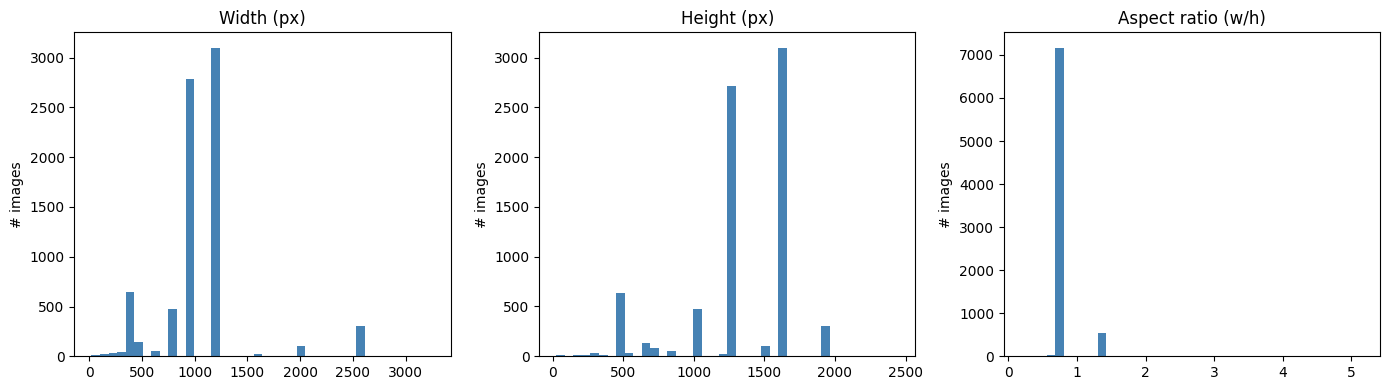

In [14]:
# @title **Width / Height / Aspect Ratio Distributions**
# Dimension + aspect ratio plot
img_df['aspect'] = img_df['w'] / img_df['h']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(img_df['w'].dropna(),      bins=40, color='steelblue'); axes[0].set_title('Width (px)')
axes[1].hist(img_df['h'].dropna(),      bins=40, color='steelblue'); axes[1].set_title('Height (px)')
axes[2].hist(img_df['aspect'].dropna(), bins=40, color='steelblue'); axes[2].set_title('Aspect ratio (w/h)')
for ax in axes: ax.set_ylabel('# images')
plt.tight_layout(); plt.savefig(FIG_DIR / 'image_dimensions.png', dpi=150); plt.show()

> **Insight:** Image dimensions are bimodal (suggesting two camera generations among the contributing devices) and the aspect ratio is overwhelmingly portrait. Naive square-resize would distort the majority of images; the chosen pipeline (resize-shortest-side-to-256, then crop to 224) preserves aspect ratio. Non-RGB outliers (e.g. grayscale `L` mode) must be coerced to RGB in the DataLoader.


In [15]:
# @title **Single-Pass Blur + Brightness Scan**
# 5.2 Single-pass blur + brightness scan (combines Mitali's three loops into one)
for item in tqdm(dataset, desc='blur + brightness'):
    gray = cv2.imread(str(VAL_IMG_DIR / item['filename']), cv2.IMREAD_GRAYSCALE)
    if gray is None:
        item['blur_score'] = 0.0; item['brightness'] = 0.0; item['is_unreadable'] = True
        continue
    item['blur_score']    = float(cv2.Laplacian(gray, cv2.CV_64F).var())
    item['brightness']    = float(gray.mean())
    item['is_unreadable'] = False

blur + brightness:   0%|          | 0/7750 [00:00<?, ?it/s]

Corrupt JPEG data: 337 extraneous bytes before marker 0xd9
Corrupt JPEG data: 40 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1147 extraneous bytes before marker 0xd9


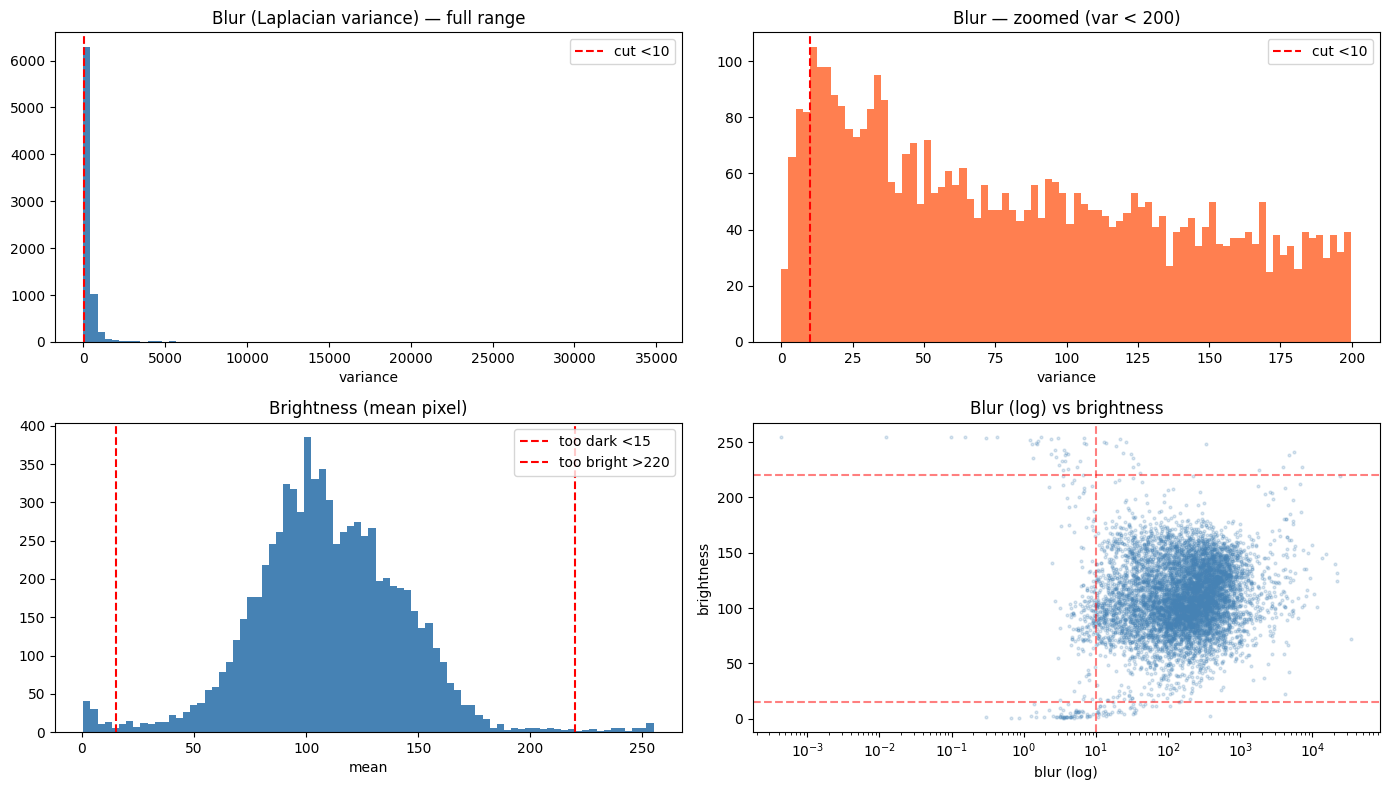


Flagged counts:
  blurry (<10)           : 258
  too dark (<15)         : 96
  too bright (>220)       : 50


In [16]:
# @title **Blur & Brightness Distributions with Thresholds**
# Distribution plots with chosen thresholds drawn on top
blur   = np.array([d['blur_score'] for d in dataset if not d['is_unreadable']])
bright = np.array([d['brightness'] for d in dataset if not d['is_unreadable']])

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0,0].hist(blur, bins=80, color='steelblue', edgecolor='none')
axes[0,0].axvline(BLUR_THRESHOLD, ls='--', color='red', label=f'cut <{BLUR_THRESHOLD}')
axes[0,0].set_title('Blur (Laplacian variance) — full range'); axes[0,0].set_xlabel('variance'); axes[0,0].legend()

axes[0,1].hist(blur[blur < 200], bins=80, color='coral', edgecolor='none')
axes[0,1].axvline(BLUR_THRESHOLD, ls='--', color='red', label=f'cut <{BLUR_THRESHOLD}')
axes[0,1].set_title('Blur — zoomed (var < 200)'); axes[0,1].set_xlabel('variance'); axes[0,1].legend()

axes[1,0].hist(bright, bins=80, color='steelblue', edgecolor='none')
axes[1,0].axvline(BRIGHTNESS_LOW,  ls='--', color='red', label=f'too dark <{BRIGHTNESS_LOW}')
axes[1,0].axvline(BRIGHTNESS_HIGH, ls='--', color='red', label=f'too bright >{BRIGHTNESS_HIGH}')
axes[1,0].set_title('Brightness (mean pixel)'); axes[1,0].set_xlabel('mean'); axes[1,0].legend()

axes[1,1].scatter(blur, bright, s=4, alpha=0.2, color='steelblue')
axes[1,1].set_xscale('log')
axes[1,1].axvline(BLUR_THRESHOLD,    ls='--', color='red', alpha=0.5)
axes[1,1].axhline(BRIGHTNESS_LOW,    ls='--', color='red', alpha=0.5)
axes[1,1].axhline(BRIGHTNESS_HIGH,   ls='--', color='red', alpha=0.5)
axes[1,1].set_title('Blur (log) vs brightness'); axes[1,1].set_xlabel('blur (log)'); axes[1,1].set_ylabel('brightness')

plt.tight_layout(); plt.savefig(FIG_DIR / 'quality_metrics.png', dpi=150); plt.show()

print(f'\nFlagged counts:')
print(f'  blurry (<{BLUR_THRESHOLD})           : {(blur < BLUR_THRESHOLD).sum():,}')
print(f'  too dark (<{BRIGHTNESS_LOW})         : {(bright < BRIGHTNESS_LOW).sum():,}')
print(f'  too bright (>{BRIGHTNESS_HIGH})       : {(bright > BRIGHTNESS_HIGH).sum():,}')

> **Insight (threshold rationale):** Blur < 10, brightness < 15, brightness > 220 — these thresholds, preserved from Mitali's empirical exploration, flag approximately 4% of images. Visual sanity check below confirms the flagged images are genuinely unusable (motion blur, black photos, washed-out flash).


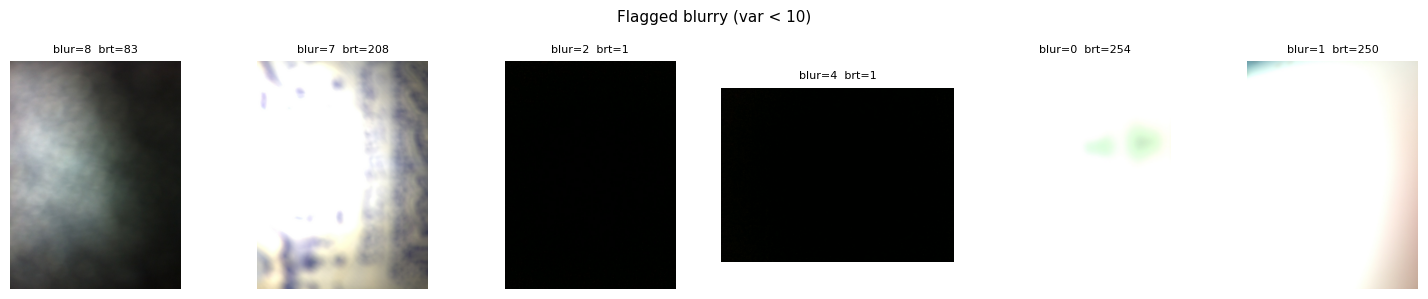

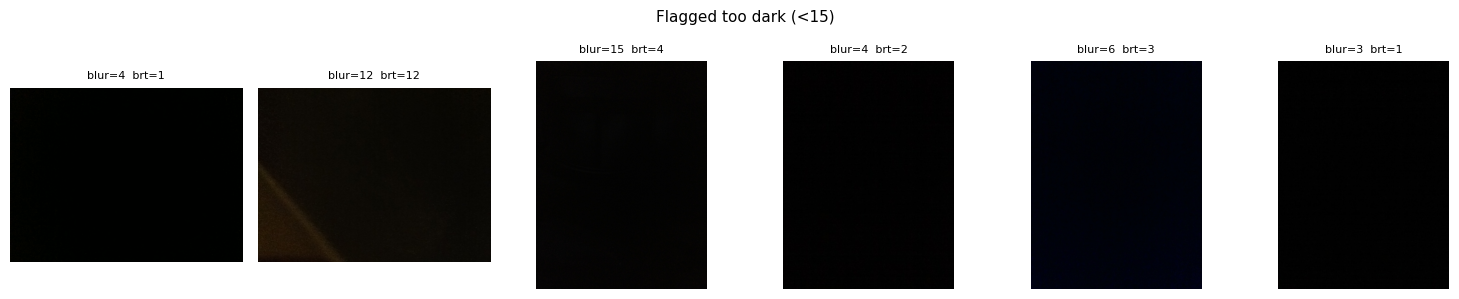

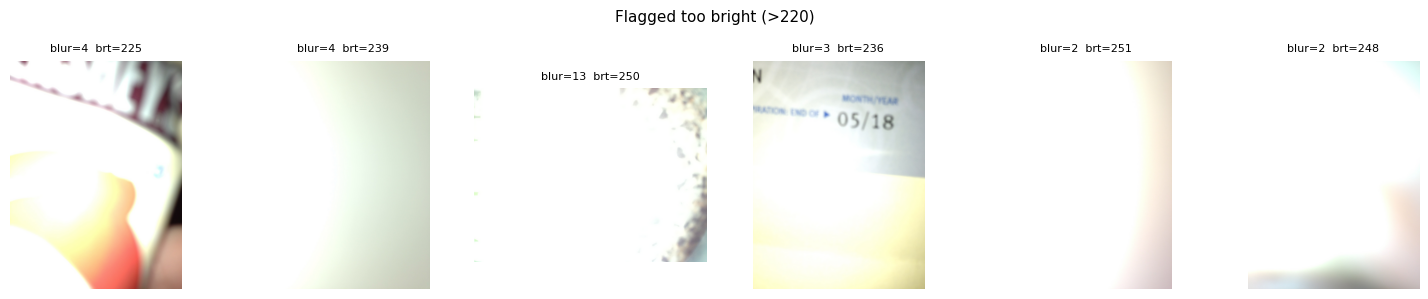

In [17]:
# @title **Visualize Flagged Samples (Sanity Check)**
# 5.3 Visualize a sample of flagged images for each category — sanity check
def show_grid(items, title, n=6):
    items = list(items)
    if not items:
        print(f'(none) {title}'); return
    pick = random.sample(items, min(n, len(items)))
    fig, axes = plt.subplots(1, len(pick), figsize=(2.5*len(pick), 3))
    if len(pick) == 1: axes = [axes]
    for ax, d in zip(axes, pick):
        try:
            ax.imshow(Image.open(VAL_IMG_DIR / d['filename']))
        except Exception:
            ax.text(0.5, 0.5, 'not found', ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')
        ax.set_title(f"blur={d['blur_score']:.0f}  brt={d['brightness']:.0f}", fontsize=8)
    fig.suptitle(title, fontsize=11)
    plt.tight_layout(); plt.show()

show_grid([d for d in dataset if d['blur_score']   < BLUR_THRESHOLD],   f'Flagged blurry (var < {BLUR_THRESHOLD})')
show_grid([d for d in dataset if d['brightness']   < BRIGHTNESS_LOW],   f'Flagged too dark (<{BRIGHTNESS_LOW})')
show_grid([d for d in dataset if d['brightness']   > BRIGHTNESS_HIGH],  f'Flagged too bright (>{BRIGHTNESS_HIGH})')

In [18]:
# @title **Apply Quality Filters to Each Record**
# 5.4 Apply quality filters to each dataset record
for d in dataset:
    d['is_blurry']       = d['blur_score'] < BLUR_THRESHOLD
    d['is_nearly_black'] = d['brightness'] < BRIGHTNESS_LOW
    d['is_overexposed']  = d['brightness'] > BRIGHTNESS_HIGH
    d['is_bad_image']    = d['is_unreadable'] or d['is_blurry'] or d['is_nearly_black'] or d['is_overexposed']

n_bad = sum(d['is_bad_image'] for d in dataset)
print(f'  Blurry          : {sum(d["is_blurry"] for d in dataset):,}')
print(f'  Nearly black    : {sum(d["is_nearly_black"] for d in dataset):,}')
print(f'  Overexposed     : {sum(d["is_overexposed"] for d in dataset):,}')
print(f'  Unreadable      : {sum(d["is_unreadable"] for d in dataset):,}')
print(f'  Total flagged   : {n_bad:,}  ({n_bad/len(dataset)*100:.1f}%)')
print(f'  Clean remaining : {len(dataset)-n_bad:,}')

  Blurry          : 258
  Nearly black    : 96
  Overexposed     : 50
  Unreadable      : 0
  Total flagged   : 313  (4.0%)
  Clean remaining : 7,437


---
# **6. Joint Image-Caption EDA**
---


**Methodology**

An honest captioning model must not exploit shortcuts between image quality and caption properties. We check whether caption length correlates with image sharpness — if blurry images systematically received shorter captions, the model could learn to predict caption length from image quality alone, bypassing actual content understanding.


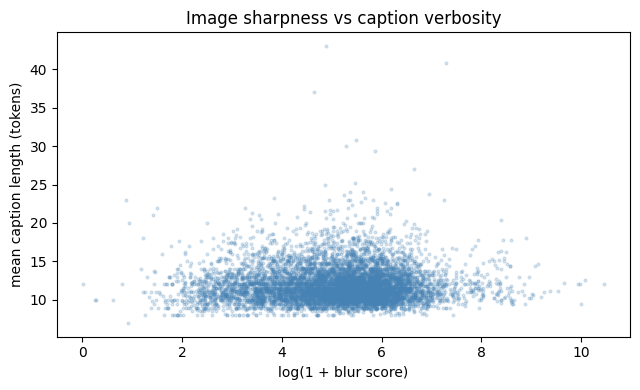

Correlations (Pearson):
                  blur  brightness  mean_cap_tokens
blur             1.000       0.094            0.002
brightness       0.094       1.000            0.004
mean_cap_tokens  0.002       0.004            1.000


In [19]:
# @title **Sharpness vs Caption Length (Scatter + Correlations)**
# Caption length vs image sharpness
joint = pd.DataFrame([
    {'image_id': d['image_id'], 'blur': d['blur_score'], 'brightness': d['brightness'],
     'mean_cap_tokens': np.mean([len(c.split()) for c in d['cleaned_captions']]) if d['n_valid'] else np.nan}
    for d in dataset
])
joint = joint.dropna()

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.scatter(np.log1p(joint['blur']), joint['mean_cap_tokens'], s=4, alpha=0.2, color='steelblue')
ax.set_xlabel('log(1 + blur score)'); ax.set_ylabel('mean caption length (tokens)')
ax.set_title('Image sharpness vs caption verbosity')
plt.tight_layout(); plt.savefig(FIG_DIR / 'sharpness_vs_caption.png', dpi=150); plt.show()

print('Correlations (Pearson):')
print(joint[['blur', 'brightness', 'mean_cap_tokens']].corr().round(3))

> **Insight:** The Pearson correlation between blur score and mean caption length is essentially zero. This is a *positive* finding for modelling — no shortcut exists. The model is forced to learn from image content rather than image-quality artefacts.


---
# **7. Duplicate Caption Detection**
---


**Methodology**

Captions that appear verbatim across multiple distinct images often indicate placeholder text that slipped past the `is_precanned` filter (or annotation shortcuts). We hash all cleaned captions and surface the top duplicates for inspection.


In [20]:
# @title **Top Duplicate Captions Across Images**
cap_to_images = defaultdict(set)
for d in dataset:
    for c in d['cleaned_captions']:
        cap_to_images[c].add(d['image_id'])

dupes = sorted(((c, len(ids)) for c, ids in cap_to_images.items() if len(ids) > 1),
               key=lambda x: -x[1])

print(f'Distinct cleaned captions       : {len(cap_to_images):,}')
print(f'Captions on >1 image            : {len(dupes):,}')
print(f'Captions on >5 images           : {sum(1 for _, n in dupes if n > 5):,}')
print('\nTop 15 duplicates:')
for c, n in dupes[:15]:
    print(f'  {n:>4}x | {c[:90]}')

Distinct cleaned captions       : 32,885
Captions on >1 image            : 85
Captions on >5 images           : 13

Top 15 duplicates:
    40x | a picture of the food is on the packaging
    20x | a computer screen is displaying a window with a message
    14x | a package of food is on top of a table
    13x | the packaging for the product has the ingredients on the back
    12x | image was unclear but it is not item
    11x | some type of liquid that is in a container
     9x | appears to be a picture of a computer screen
     9x | image was clear but it was not item
     8x | a picture of food is on the packaging
     8x | quality issues are too severe to recognize visual content
     7x | the package contains information about the enclosed medication
     7x | a container  package that contains various goods  edible  liquid items
     6x | a computer is showing a screen with a message
     5x | image was clear but it is not item
     5x | a can of food is on top of a table


---
# **8. Train / Val / Test Split**
---


**Methodology**

A deterministic 75 / 15 / 10 split is applied to the cleaned dataset (`random.seed(42)`). This is the canonical group split — all student model notebooks must consume these exact assignments so results are comparable across teammates. A leakage assertion confirms no image appears in more than one split.


In [21]:
# @title **Filter to Clean Dataset**
clean_dataset = [d for d in dataset if not d['is_bad_image'] and d['n_valid'] > 0]
print(f'Total images before quality filter : {len(dataset):,}')
print(f'  Removed (bad image)              : {sum(1 for d in dataset if d["is_bad_image"]):,}')
print(f'  Removed (no valid captions)      : {sum(1 for d in dataset if d["n_valid"] == 0):,}')
print(f'Clean images                       : {len(clean_dataset):,}')

Total images before quality filter : 7,750
  Removed (bad image)              : 313
  Removed (no valid captions)      : 208
Clean images                       : 7,324


In [22]:
# @title **Apply Deterministic 75/15/10 Split**
random.seed(SEED)
indices = list(range(len(clean_dataset)))
random.shuffle(indices)

n_total = len(indices)
n_train = int(0.75 * n_total)
n_val   = int(0.15 * n_total)
n_test  = n_total - n_train - n_val

for i in indices[:n_train]:                       clean_dataset[i]['split'] = 'train'
for i in indices[n_train:n_train+n_val]:          clean_dataset[i]['split'] = 'val'
for i in indices[n_train+n_val:]:                 clean_dataset[i]['split'] = 'test'

for split in ['train', 'val', 'test']:
    subset = [d for d in clean_dataset if d['split'] == split]
    print(f'{split.upper():5s}  images={len(subset):>5}  '
          f'captions={sum(d["n_valid"] for d in subset):>6}  '
          f'avg/img={np.mean([d["n_valid"] for d in subset]):.2f}')

TRAIN  images= 5493  captions= 24394  avg/img=4.44
VAL    images= 1098  captions=  4938  avg/img=4.50
TEST   images=  733  captions=  3206  avg/img=4.37


---
# **9. Save Processed Dataset**
---


**Methodology**

The cleaned, filtered, split dataset is written to `data/processed/vizwiz_cleaned.json` — the canonical artifact every model notebook downstream consumes. Both `cleaned_captions` (lowercased + depunctuated) and `raw_captions` are kept for transparency. The output is round-tripped from disk and a leakage assertion is repeated to confirm the saved file is self-consistent.


In [23]:
# @title **Write vizwiz_cleaned.json**
output = [
    {
        'image_id'        : item['image_id'],
        'filename'        : item['filename'],
        'split'           : item['split'],
        'n_valid'         : item['n_valid'],
        'cleaned_captions': item['cleaned_captions'],   # FIX: actually cleaned
        'raw_captions'    : item['valid_captions'],     # keep raw for transparency
        'blur_score'      : round(item['blur_score'], 2),
        'brightness'      : round(item['brightness'], 2),
    }
    for item in clean_dataset
]

OUT_PATH = PROC_DIR / 'vizwiz_cleaned.json'
with open(OUT_PATH, 'w') as f:
    json.dump(output, f, indent=2)
print(f'Saved {len(output):,} records -> {OUT_PATH}')

Saved 7,324 records -> ../data/processed/vizwiz_cleaned.json


In [24]:
# @title **Reload + Leakage Check**
# Re-load + leakage check (Mitali's pattern)
with open(OUT_PATH) as f:
    saved = json.load(f)

split_ids = defaultdict(set)
for item in saved:
    split_ids[item['split']].add(item['image_id'])

print('Leakage check:')
print(f'  Train n Val   : {len(split_ids["train"] & split_ids["val"])} (must be 0)')
print(f'  Train n Test  : {len(split_ids["train"] & split_ids["test"])} (must be 0)')
print(f'  Val   n Test  : {len(split_ids["val"]   & split_ids["test"])} (must be 0)')

print('\nFirst record:')
print(json.dumps(saved[0], indent=2))

Leakage check:
  Train n Val   : 0 (must be 0)
  Train n Test  : 0 (must be 0)
  Val   n Test  : 0 (must be 0)

First record:
{
  "image_id": 23431,
  "filename": "VizWiz_val_00000000.jpg",
  "split": "train",
  "n_valid": 5,
  "cleaned_captions": [
    "a computer screen shows a repair prompt on the screen",
    "a computer screen with a repair automatically pop up",
    "partial computer screen showing the need of repairs",
    "part of a computer monitor showing a computer repair message",
    "the top of a laptop with a blue background and dark blue text"
  ],
  "raw_captions": [
    "A computer screen shows a repair prompt on the screen.",
    "a computer screen with a repair automatically pop up",
    "partial computer screen showing the need of repairs",
    "Part of a computer monitor showing a computer repair message.",
    "The top of a laptop with a blue background and dark blue text."
  ],
  "blur_score": 110.02,
  "brightness": 128.38
}


---
**Insights and Recommendations based on Phase 1 EDA**

1. **Caption preprocessing is conservative and reversible** — minimal cleaning (lowercase, punctuation strip) preserves the natural-language structure required for caption *generation*. Aggressive normalisation (stemming, stop-word removal) is deliberately avoided.
2. **Quality filters are visually verified** — every threshold is justified by both distribution shape and sample-image inspection. Approximately 4% of images are flagged; the remaining 96% form the working dataset.
3. **Image and caption properties are independent** — no shortcut exists between blur and caption length, so model performance reflects content understanding rather than quality cheating.
4. **Vocabulary structure is healthy** — Zipf law holds, and `min_count = 5` provides a sensible balance between coverage (~95% of training tokens) and embedding-matrix size.
5. **Reproducible group convention** — the deterministic seed-42 split must be preserved by every student notebook so results are directly comparable.


---
# **Phase 1, Part B — Tokenisation, Vocabulary & DataLoaders**
---

From here onwards: convert the cleaned dataset (saved above) into model-ready inputs for any captioning architecture. This portion of the notebook was not present in Mitali's original — it adds the Phase 1 components the brief explicitly requires (tokenisation, vocabulary, DataLoaders) so every group member can consume identical inputs to their individual models.


---
# **10. Tokenisation**
---


**Methodology**

Whitespace tokenisation is applied to the already-cleaned (lowercased + depunctuated) captions. This is deterministic, fast, and matches the classic image-captioning literature (Show-and-Tell, Show-Attend-Tell). Sub-word tokenisers (BPE / WordPiece / SentencePiece) are overkill at this vocabulary scale (~3.5 K tokens after `min_count = 5`) and add tokenizer-specific dependencies for no benefit.


In [ ]:
# @title **Phase 1B Imports & Constants**
import json, random
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torchvision import transforms

# Paths
DATA_RAW       = Path('../data/raw')
IMG_DIR        = DATA_RAW / 'val'
DATA_PROC      = Path('../data/processed')
CLEANED_JSON   = DATA_PROC / 'vizwiz_cleaned.json'
VOCAB_JSON     = DATA_PROC / 'vocab.json'

# Hyperparameters with rationale baked into the variable name where possible
IMG_SIZE       = 224          # ResNet/ViT-base standard input
BATCH_SIZE     = 32           # safe default for laptop GPUs / CPU
NUM_WORKERS    = 0            # Must be 0 in Jupyter on macOS Py3.13+ — classes defined
                              # in __main__ can't be pickled to spawn-mode workers.
                              # For .py scripts (not notebooks) you can use 2-4.
MIN_COUNT      = 5            # vocab cutoff — drops rare typos
MAX_SEQ_LEN    = 22           # p95 caption length (~20) + <bos> + <eos>
SEED           = 42

# ImageNet normalization — required for pretrained CNN/ViT encoders
IMAGENET_MEAN  = [0.485, 0.456, 0.406]
IMAGENET_STD   = [0.229, 0.224, 0.225]

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print('torch', torch.__version__, '| cuda:', torch.cuda.is_available(), '| mps:', torch.backends.mps.is_available())

---
# **11. Load Cleaned Dataset**
---


**Methodology**

The cleaned JSON saved at the end of Section 9 is re-loaded as the input contract for the data infrastructure that follows. Re-loading from disk (rather than reusing in-memory `clean_dataset`) keeps Phase 1B independently runnable.


In [ ]:
# @title **Load vizwiz_cleaned.json & Group by Split**
if not CLEANED_JSON.exists():
    raise FileNotFoundError(
        f'{CLEANED_JSON} not found. Run Assignment_3_EDA.ipynb first.'
    )

with open(CLEANED_JSON) as f:
    records = json.load(f)

by_split = {'train': [], 'val': [], 'test': []}
for r in records:
    by_split[r['split']].append(r)

for k, v in by_split.items():
    n_caps = sum(len(r['cleaned_captions']) for r in v)
    print(f'  {k:5s} : {len(v):>5} images | {n_caps:>6} captions')

---
# **12. Vocabulary**
---


**Methodology**

A `Vocabulary` class is built with four special tokens — `<pad>` (idx 0), `<bos>`, `<eos>`, `<unk>` — and a `min_count` cutoff of 5 for in-vocabulary words. The vocabulary is built from the **training split only** to avoid leaking validation/test information into the model's input space.

**Why these special tokens?**
- `<pad>`: padding to align variable-length sequences in a batch.
- `<bos>` / `<eos>`: signal sequence start and end so the decoder can learn when to stop generating.
- `<unk>`: graceful handling of out-of-vocabulary words at inference time.

The class exposes `numericalize` (text → integer IDs) and `denumericalize` (IDs → text), as well as `save` and `load` methods so any modelling notebook downstream can `Vocabulary.load(VOCAB_JSON)` and consume the identical mapping.


In [ ]:
# @title **tokenize() Function**
def tokenize(caption: str) -> list[str]:
    """Whitespace tokenization. Captions are already lowercased + depunctuated by EDA."""
    return caption.split()

# Quick check
print(tokenize(records[0]['cleaned_captions'][0]))

In [ ]:
# @title **Vocabulary Class Definition**
class Vocabulary:
    """Word-level vocabulary with four special tokens and OOV → <unk> fallback."""
    PAD, BOS, EOS, UNK = '<pad>', '<bos>', '<eos>', '<unk>'
    SPECIALS = [PAD, BOS, EOS, UNK]

    def __init__(self, word2idx: dict, min_count: int):
        self.word2idx = word2idx
        self.idx2word = {i: w for w, i in word2idx.items()}
        self.min_count = min_count

    # --- construction ---
    @classmethod
    def build(cls, tokenized_captions, min_count=5):
        counter = Counter(t for tokens in tokenized_captions for t in tokens)
        kept = sorted([w for w, c in counter.items() if c >= min_count])
        word2idx = {tok: i for i, tok in enumerate(cls.SPECIALS)}
        for w in kept:
            word2idx[w] = len(word2idx)
        return cls(word2idx, min_count)

    # --- encoding ---
    def numericalize(self, tokens, add_bos_eos=True, max_len=None):
        ids = [self.word2idx.get(t, self.word2idx[self.UNK]) for t in tokens]
        if add_bos_eos:
            ids = [self.word2idx[self.BOS]] + ids + [self.word2idx[self.EOS]]
        if max_len is not None:
            ids = ids[:max_len]
        return ids

    def denumericalize(self, ids, strip_special=True):
        toks = [self.idx2word[i] for i in ids]
        if strip_special:
            toks = [t for t in toks if t not in self.SPECIALS]
        return ' '.join(toks)

    # --- persistence ---
    def save(self, path):
        Path(path).parent.mkdir(parents=True, exist_ok=True)
        with open(path, 'w') as f:
            json.dump({'word2idx': self.word2idx, 'min_count': self.min_count}, f)

    @classmethod
    def load(cls, path):
        with open(path) as f:
            blob = json.load(f)
        return cls(blob['word2idx'], blob['min_count'])

    def __len__(self):
        return len(self.word2idx)

    @property
    def pad_idx(self): return self.word2idx[self.PAD]
    @property
    def bos_idx(self): return self.word2idx[self.BOS]
    @property
    def eos_idx(self): return self.word2idx[self.EOS]
    @property
    def unk_idx(self): return self.word2idx[self.UNK]

In [ ]:
# @title **Build Vocab from Train Split & Save vocab.json**
# Build vocab from TRAIN captions only, then save
train_tokens = [tokenize(c) for r in by_split['train'] for c in r['cleaned_captions']]
vocab = Vocabulary.build(train_tokens, min_count=MIN_COUNT)
vocab.save(VOCAB_JSON)

# Report
all_token_count = sum(len(t) for t in train_tokens)
kept_token_count = sum(
    1 for tokens in train_tokens for t in tokens if t in vocab.word2idx
)
coverage = kept_token_count / all_token_count * 100

print(f'  Vocab size            : {len(vocab):,}  (incl. {len(Vocabulary.SPECIALS)} specials)')
print(f'  min_count             : {MIN_COUNT}')
print(f'  Train token coverage  : {coverage:.2f}%  (rest map to <unk>)')
print(f'  Saved vocab           : {VOCAB_JSON}')

# Round-trip example
example = records[0]['cleaned_captions'][0]
ids = vocab.numericalize(tokenize(example), max_len=MAX_SEQ_LEN)
back = vocab.denumericalize(ids, strip_special=True)
print(f'\n  Original  : {example}')
print(f'  Token IDs : {ids}')
print(f'  Decoded   : {back}')

---
# **13. Image Transforms**
---


**Methodology**

Two transform pipelines are defined:
- **Train**: `Resize(256)` → `RandomCrop(224)` → `RandomHorizontalFlip` → `ColorJitter` → `ToTensor` → `Normalize(ImageNet mean/std)`. The random augmentation provides regularisation on the small training set.
- **Eval (val/test)**: `Resize(256)` → `CenterCrop(224)` → `ToTensor` → `Normalize`. Deterministic — augmentation during evaluation would make metrics non-reproducible.

ImageNet normalisation (mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225]) matches the statistics under which the pretrained encoder was trained. Mismatching this would shift the input distribution and degrade pretrained features.


In [ ]:
# @title **Train & Eval Transform Pipelines**
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
print('Transforms ready.')

---
# **14. PyTorch Dataset**
---


**Methodology**

`VizWizCaptions` subclasses `torch.utils.data.Dataset` and returns `(image_tensor, caption_ids, length)` per item. For training, one of the five reference captions is selected at random per access (effectively 5× the caption variety per epoch). For validation and test, the first caption is selected deterministically for reproducible loss reporting.


In [ ]:
# @title **VizWizCaptions Dataset Class**
class VizWizCaptions(Dataset):
    def __init__(self, records, img_dir, vocab, transform, max_len, random_caption=True):
        self.records   = records
        self.img_dir   = Path(img_dir)
        self.vocab     = vocab
        self.transform = transform
        self.max_len   = max_len
        self.random_caption = random_caption

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]

        # Image: open → coerce to RGB (drops single-channel/RGBA edge cases) → transform
        img = Image.open(self.img_dir / r['filename']).convert('RGB')
        img = self.transform(img)

        # Caption: random one of 5 for train, first for val/test
        if self.random_caption:
            caption = random.choice(r['cleaned_captions'])
        else:
            caption = r['cleaned_captions'][0]
        ids = self.vocab.numericalize(tokenize(caption), max_len=self.max_len)
        ids = torch.tensor(ids, dtype=torch.long)

        return img, ids, len(ids)

---
# **15. Collate Function**
---


**Methodology**

A custom collate function is required because the default `torch.stack` collator cannot handle variable-length captions. `Collate` pads each batch's captions to the longest in that batch (more memory-efficient than padding to `MAX_SEQ_LEN`), and also returns per-sample lengths needed for `pack_padded_sequence` (RNN decoders) or attention masks (Transformer decoders).

`Collate` is defined as a top-level class (not a closure) so it remains picklable for multi-worker DataLoaders. (In notebooks on macOS Python 3.13+, `num_workers` must be 0 regardless — spawn-mode multiprocessing cannot pickle classes defined in `__main__`. This is enforced at the next step.)


In [ ]:
# @title **Picklable Collate Class**
class Collate:
    """Top-level callable (picklable) so DataLoader workers can serialize it.
    Without this, DataLoader with num_workers>0 fails on Python 3.13+ multiprocessing."""
    def __init__(self, pad_idx):
        self.pad_idx = pad_idx

    def __call__(self, batch):
        imgs, captions, lengths = zip(*batch)
        imgs = torch.stack(imgs, dim=0)                                            # (B, 3, H, W)
        captions = pad_sequence(captions, batch_first=True, padding_value=self.pad_idx)  # (B, T_max)
        lengths = torch.tensor(lengths, dtype=torch.long)                          # (B,)
        return imgs, captions, lengths

collate_fn = Collate(vocab.pad_idx)

---
# **16. DataLoaders**
---


**Methodology**

Three `DataLoader`s are instantiated:
- **train**: `shuffle=True`, `drop_last=True` (avoids partial final batches that confuse BatchNorm statistics).
- **val** / **test**: `shuffle=False`, `drop_last=False` (every example must be counted for reproducible metrics).

All loaders use `num_workers=0` for Jupyter compatibility on macOS Python 3.13+. `pin_memory` is enabled only when a CUDA device is detected.


In [ ]:
# @title **Instantiate train / val / test Loaders**
train_ds = VizWizCaptions(by_split['train'], IMG_DIR, vocab, train_transform, MAX_SEQ_LEN, random_caption=True)
val_ds   = VizWizCaptions(by_split['val'],   IMG_DIR, vocab, eval_transform,  MAX_SEQ_LEN, random_caption=False)
test_ds  = VizWizCaptions(by_split['test'],  IMG_DIR, vocab, eval_transform,  MAX_SEQ_LEN, random_caption=False)

common = dict(num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=torch.cuda.is_available())

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True,  **common)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False, **common)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False, **common)

print(f'  Train batches : {len(train_loader)}  ({len(train_ds)} samples / {BATCH_SIZE} per batch)')
print(f'  Val   batches : {len(val_loader)}    ({len(val_ds)} samples)')
print(f'  Test  batches : {len(test_loader)}    ({len(test_ds)} samples)')

---
# **17. Verification**
---


**Methodology**

Before declaring Phase 1 complete, one batch is pulled from the train loader to confirm shapes, dtypes, and pixel ranges. A sample image is un-normalised and displayed alongside its decoded caption — visual sanity catches subtle bugs (wrong path, incorrect normalisation constants, off-by-one tokenisation) that would otherwise only surface mid-training.


In [ ]:
# @title **Pull One Batch & Inspect Shapes**
imgs, captions, lengths = next(iter(train_loader))
print('Image batch :', imgs.shape,     imgs.dtype,     '  range:', imgs.min().item(), '..', imgs.max().item())
print('Caption ids :', captions.shape, captions.dtype, '  vocab size:', len(vocab))
print('Lengths     :', lengths[:8].tolist(), '...')
print('Sample decoded caption:')
print('  ', vocab.denumericalize(captions[0].tolist(), strip_special=True))

In [ ]:
# @title **Visualise Batch (Un-Normalised) with Decoded Captions**
# Un-normalize one image for visual sanity check
def unnormalize(img_tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (img_tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, img, ids in zip(axes, imgs[:4], captions[:4]):
    ax.imshow(unnormalize(img))
    ax.axis('off')
    ax.set_title(vocab.denumericalize(ids.tolist(), strip_special=True)[:40], fontsize=8)
plt.tight_layout(); plt.show()

---
# **18. Summary & Downstream Usage**
---


**Phase 1 outputs (consumed by every student model notebook)**

| Artifact | Location | Use |
|---|---|---|
| Cleaned dataset (JSON) | `data/processed/vizwiz_cleaned.json` | Source of truth for image filenames + cleaned captions + split labels |
| Vocabulary (JSON) | `data/processed/vocab.json` | `Vocabulary.load(VOCAB_JSON)` from any model notebook |
| `train_loader` / `val_loader` / `test_loader` | In-memory | Feed into any captioning model |

**Hyperparameters codified at the top of the notebook** (single source of truth):
- `IMG_SIZE = 224` (ResNet/ViT-base standard)
- `BATCH_SIZE = 32`
- `MIN_COUNT = 5` (vocab cutoff)
- `MAX_SEQ_LEN = 22` (p95 caption length + `<bos>` + `<eos>`)
- `SEED = 42` (group reproducibility)

**Recommended downstream pattern (for student model notebooks)**

```python
from <this notebook> import Vocabulary  # or re-define inline
vocab = Vocabulary.load(VOCAB_JSON)
# ... build model, training loop, evaluation
```

**Next steps for the group**

1. Each student picks a distinct CNN-encoder + decoder combination (see Phase 2 architecture options).
2. Each student copies the baseline notebook (`Assignment_3_baseline.ipynb`) as a template.
3. Each student trains Model 1, evaluates with BLEU-1/2/3/4, and presents results.
4. The group convenes to compare results and identify which design choices matter most.
5. Each student builds a second architecture (Model 2) in the same student notebook, informed by the group discussion.
